# LAB 6 : Recurrent Neural Networks

Name : Sabyasachi Ghosal    

Roll Number : 24PHDDI05

Referrence Material :

1. https://github.com/pangolulu/rnn-from-scratch
2. https://www.analyticsvidhya.com/blog/2019/01/fundamentals-deep-learning-recurrent-neural-networks-scratch-python/


#**Problem 1** : Next Token Prediction in a Sequence

Observation to be demonstrated:

1. Generate the data required
2. Represent tokens as indices using dictionaries
3. Convert the tokens into vectors using One hot encoding
4. Implement Recurrent Neural Network to solve the Next token prediction problem

##Write down the Objectives, Hypothesis and Experimental description for the above problem



## Programming :


1. **Representing tokens or text**

In previous labs we mainly considered data $x \in \mathrm{R}^d$, where $d$ is the feature space dimension.
With time sequences our data can be represented as $x \in \mathrm{R}^{t \, \times \, d}$, where $t$ is the sequence length.
This emphasises sequence dependence and that the samples along the sequence are not independent and identically distributed (i.i.d.).
We will model functions as $\mathrm{R}^{t \, \times \, d} \rightarrow \mathrm{R}^c$, where $c$ is the amount of classes in the output.

There are several ways to represent sequences. With text, the challenge is how to represent a word as a feature vector in $d$ dimensions, as we are required to represent text with decimal numbers in order to apply neural networks to it.

In this exercise we will use a simple one-hot encoding but for categorical variables that can take on many values (e.g. words in the English language) this may be infeasible. For such scenarios, you can project the encodings into a smaller space by use of embeddings.

2. **One-hot encoding over vocabulary**

One way to represent a fixed amount of words is by making a one-hot encoded vector, which consists of 0s in all cells with the exception of a single 1 in a cell used uniquely to identify each word.

| vocabulary    | one-hot encoded vector   |
| ------------- |--------------------------|
| Paris         | $= [1, 0, 0, \ldots, 0]$ |
| Rome          | $= [0, 1, 0, \ldots, 0]$ |
| Copenhagen    | $= [0, 0, 1, \ldots, 0]$ |

Representing a large vocabulary with one-hot encodings often becomes inefficient because of the size of each sparse vector.
To overcome this challenge it is common practice to truncate the vocabulary to contain the $k$ most used words and represent the rest with a special symbol, $\mathtt{UNK}$, to define unknown/unimportant words.
This often causes entities such as names to be represented with $\mathtt{UNK}$ because they are rare.

Consider the following text
> I love the corny jokes in Spielberg's new movie.

where an example result would be similar to
> I love the corny jokes in $\mathtt{UNK}$'s new movie.

## Generating a dataset

For this exercise we will create a simple dataset that we can learn from. We generate sequences of the form:

`a a a a b b b b EOS`, `a a b b EOS`, `a a a a a b b b b b EOS`

where `EOS` is a special character denoting the end of a sequence. The task is to predict the next token $t_n$, i.e. `a`, `b`, `EOS` or the unknown token `UNK` given the sequence of tokens $\{ t_{1}, t_{2}, \dots , t_{n-1}\}$ and we are to process sequences in a sequential manner. As such, the network will need to learn that e.g. 5 `b`s and an `EOS` token will occur following 5 `a`s.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed such that we always get the same dataset
np.random.seed(42)

def generate_dataset(num_sequences=100):
    """
    Generates a number of sequences as our dataset.

    Args:
     `num_sequences`: the number of sequences to be generated.

    Returns a list of sequences.
    """
    samples = []

    for _ in range(num_sequences):
        num_tokens = np.random.randint(1, 10)
        sample = ['a'] * num_tokens + ['b'] * num_tokens + ['EOS']
        samples.append(sample)

    return samples


sequences = generate_dataset()

print('A single sample from the generated dataset:')
print(sequences[0])

A single sample from the generated dataset:
['a', 'a', 'a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'EOS']


## Representing tokens as indices

To build a one-hot encoding, we need to assign each possible word in our vocabulary an index. We do that by creating two dictionaries: one that allows us to go from a given word to its corresponding index in our vocabulary, and one for the reverse direction. Let's call them `word_to_idx` and `idx_to_word`. The keyword `num_words` specifies the maximum size of our vocabulary. If we try to access a word that does not exist in our vocabulary, it is automatically replaced by the `UNK` token or its corresponding index.

In [2]:
from collections import defaultdict

def sequences_to_dicts(sequences):
    """
    Creates word_to_idx and idx_to_word dictionaries for a list of sequences.
    """
    # A bit of Python-magic to flatten a nested list
    flatten = lambda l: [item for sublist in l for item in sublist]

    # Flatten the dataset
    all_words = flatten(sequences)

    # Count number of word occurences
    word_count = defaultdict(int)
    for word in flatten(sequences):
        word_count[word] += 1

    # Sort by frequency
    word_count = sorted(list(word_count.items()), key=lambda l: -l[1])

    # Create a list of all unique words
    unique_words = [item[0] for item in word_count]

    # Add UNK token to list of words
    unique_words.append('UNK')

    # Count number of sequences and number of unique words
    num_sentences, vocab_size = len(sequences), len(unique_words)

    # Create dictionaries so that we can go from word to index and back
    # If a word is not in our vocabulary, we assign it to token 'UNK'
    word_to_idx = defaultdict(lambda: num_words)
    idx_to_word = defaultdict(lambda: 'UNK')

    # Fill dictionaries
    for idx, word in enumerate(unique_words):
        # YOUR CODE HERE!
        word_to_idx[word] = idx
        idx_to_word[idx] = word

    return word_to_idx, idx_to_word, num_sentences, vocab_size


word_to_idx, idx_to_word, num_sequences, vocab_size = sequences_to_dicts(sequences)

print(f'We have {num_sequences} sentences and {len(word_to_idx)} unique tokens in our dataset (including UNK).\n')
print('The index of \'b\' is', word_to_idx['b'])
print(f'The word corresponding to index 1 is \'{idx_to_word[1]}\'')

We have 100 sentences and 4 unique tokens in our dataset (including UNK).

The index of 'b' is 1
The word corresponding to index 1 is 'b'


## Creating Dataset

To build our dataset, we need to create inputs and targets for each sequences and partition sentences into training and test sets. 80% and 20% is a common distribution, but mind you that this largely depends on the size of the dataset. **Since we are doing next-word predictions, our target sequence is simply the input sequence shifted by one word.**

In [3]:
from torch.utils import data

class Dataset(data.Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        # Return the size of the dataset
        return len(self.targets)

    def __getitem__(self, index):
        # Retrieve inputs and targets at the given index
        X = self.inputs[index]
        y = self.targets[index]

        return X, y


def create_datasets(sequences, dataset_class, p_train=0.8, p_val=0.1, p_test=0.1):
    # Define partition sizes
    num_train = int(len(sequences)*p_train)
    num_val = int(len(sequences)*p_val)
    num_test = int(len(sequences)*p_test)

    # Split sequences into partitions
    sequences_train = sequences[:num_train]
    sequences_val = sequences[num_train:num_train+num_val]
    sequences_test = sequences[-num_test:]

    def get_inputs_targets_from_sequences(sequences):
        # Define empty lists
        inputs, targets = [], []

        # Append inputs and targets s.t. both lists contain L-1 words of a sentence of length L
        # but targets are shifted right by one so that we can predict the next word
        for sequence in sequences:
            inputs.append(sequence[:-1])
            targets.append(sequence[1:])

        return inputs, targets

    # Get inputs and targets for each partition
    inputs_train, targets_train = get_inputs_targets_from_sequences(sequences_train)
    inputs_val, targets_val = get_inputs_targets_from_sequences(sequences_val)
    inputs_test, targets_test = get_inputs_targets_from_sequences(sequences_test)

    # Create datasets
    training_set = dataset_class(inputs_train, targets_train)
    validation_set = dataset_class(inputs_val, targets_val)
    test_set = dataset_class(inputs_test, targets_test)

    return training_set, validation_set, test_set


training_set, validation_set, test_set = create_datasets(sequences, Dataset)

print(f'We have {len(training_set)} samples in the training set.')
print(f'We have {len(validation_set)} samples in the validation set.')
print(f'We have {len(test_set)} samples in the test set.')

We have 80 samples in the training set.
We have 10 samples in the validation set.
We have 10 samples in the test set.


## One-hot encodings

We now create a simple function that returns the one-hot encoded representation of a given index of a word in our vocabulary. Notice that the shape of the one-hot encoding is equal to the vocabulary (which can be huge!). Additionally, we define a function to automatically one-hot encode a sentence.

In [4]:
def one_hot_encode(idx, vocab_size):
    """
    One-hot encodes a single word given its index and the size of the vocabulary.

    Args:
     `idx`: the index of the given word
     `vocab_size`: the size of the vocabulary

    Returns a 1-D numpy array of length `vocab_size`.
    """
    # Initialize the encoded array
    one_hot = np.zeros(vocab_size)

    # Set the appropriate element to one
    one_hot[idx] = 1.0

    return one_hot


def one_hot_encode_sequence(sequence, vocab_size):
    """
    One-hot encodes a sequence of words given a fixed vocabulary size.

    Args:
     `sentence`: a list of words to encode
     `vocab_size`: the size of the vocabulary

    Returns a 3-D numpy array of shape (num words, vocab size, 1).
    """
    # Encode each word in the sentence
    encoding = np.array([one_hot_encode(word_to_idx[word], vocab_size) for word in sequence])

    # Reshape encoding s.t. it has shape (num words, vocab size, 1)
    encoding = encoding.reshape(encoding.shape[0], encoding.shape[1], 1)

    return encoding


test_word = one_hot_encode(word_to_idx['a'], vocab_size)
print(f'Our one-hot encoding of \'a\' has shape {test_word.reshape([4,1]).shape}.')

test_sentence = one_hot_encode_sequence(['a', 'b'], vocab_size)
print(f'Our one-hot encoding of \'a b\' has shape {test_sentence.shape}.')

Our one-hot encoding of 'a' has shape (4, 1).
Our one-hot encoding of 'a b' has shape (2, 4, 1).


## Implementation of RNN :

A recurrent neural network (RNN) is a type of neural network that has been succesful in modelling sequential data, e.g. language, speech, protein sequences, etc.

A RNN performs its computations in a cyclic manner, where the same computation is applied to every sample of a given sequence.
The idea is that the network should be able to use the previous computations as some form of memory and apply this to future computations.
An image may best explain how this is to be understood,

![rnn-unroll image](https://github.com/DeepLearningDTU/02456-deep-learning-with-PyTorch/blob/master/static_files/rnn-unfold.png?raw=1)


where it the network contains the following elements:

- $x$ is the input sequence of samples,
- $U$ is a weight matrix applied to the given input sample,
- $V$ is a weight matrix used for the recurrent computation in order to pass memory along the sequence,
- $W$ is a weight matrix used to compute the output of the every timestep (given that every timestep requires an output),
- $h$ is the hidden state (the network's memory) for a given time step, and
- $o$ is the resulting output.

When the network is unrolled as shown, it is easier to refer to a timestep, $t$.
We have the following computations through the network:

- $h_t = f(U\,{x_t} + V\,{h_{t-1}})$, where $f$ usually is an activation function, e.g. $\mathrm{tanh}$.
- $o_t = \mathrm{softmax}(W\,{h_t})$


**Steps :**

  1. Implement Forward Pass, Backward Pass and Optimisation
  2. Write the training loop
  3. Take care of the exploding gradient problem by clipping the gradients

## Input Initialisation

In [5]:
## Initialise an RNN
hidden_units = 64  # Hidden state size
vocab_size = 4  # Vocabulary size

# Common initialization methods such as Xavier (Glorot) initialization or Kaiming initialization, 
# which are specifically designed for deep networks and are often provided by libraries like NumPy or PyTorch
def init_rnn(hidden_units, vocab_size):
    U = np.random.randn(hidden_units, vocab_size) * 0.01  # Input to hidden
    V = np.random.randn(hidden_units, hidden_units) * 0.01  # Hidden to hidden
    W = np.random.randn(vocab_size, hidden_units) * 0.01  # Hidden to output
    b_hidden = np.zeros((hidden_units, 1))  # Bias for hidden state
    b_out = np.zeros((vocab_size, 1))  # Bias for output
    print(U.shape, V.shape, W.shape)
    return U, V, W, b_hidden, b_out  # Return parameters

params = init_rnn(hidden_units=hidden_units, vocab_size=vocab_size)

(64, 4) (64, 64) (4, 64)


## Clip Gradient
Exploding gradient problem handling by limiting size of gradients. Does the following
- It calculates the norm of the gradients using their L2 norm (sum of squares).
- clip_coef scales the gradients so that their norm will not exceed max_norm.
- If clip_coef is less than 1 (meaning the gradient norm exceeds max_norm), each gradient in grads is scaled by clip_coef to limit its size


In [6]:
def clip_gradient_norm(grads, max_norm=0.25):
    # Calculate total norm of all gradients
    total_norm = np.sqrt(sum(np.sum(np.square(grad)) for grad in grads))
    
    # Calculate clipping coefficient if the total norm exceeds max_norm
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        grads = [grad * clip_coef for grad in grads]
    
    return grads

def update_parameters(params, grads, lr=1e-3):
   return [param - lr * grad for param, grad in zip(params, grads)]

In [7]:
def tanh(x, gradient=False):
    f = np.tanh(x)
    return 1 - f**2 if gradient else f  # Return gradient or forward pass

def softmax(x, gradient=False):
    f = np.exp(x) / np.sum(np.exp(x))  # Softmax function
    return f

## BackPropagation
- Computes the cross-entropy loss for the output at time t. A small value (1e-12) is added to prevent log(0).
- Calculates the gradient of the loss with respect to the output. It modifies d_o by subtracting 1 from the position of the target class.
- Computes the gradient of the hidden state using the output gradients and the weights connecting the hidden state to the output. It also accounts for the gradient coming from the next time step
- Accumulates gradients for the weights and biases.
- Updates the gradient for the hidden-to-hidden weights (d_V). If not the first time step, it uses the previous hidden state; otherwise, it uses a zero vector.

In [18]:
def backpass(outputs, targets, hidden_states, inputs, params, clip_gradients=False, max_norm=0.25):
    U, V, W, b_hidden, b_out = params
    total_loss = 0
    d_U, d_V, d_W = np.zeros_like(U), np.zeros_like(V), np.zeros_like(W)
    d_b_hidden, d_b_out = np.zeros_like(b_hidden), np.zeros_like(b_out)
    seq_length = len(outputs)
    d_h_next = np.zeros_like(hidden_states[0])

    for t in reversed(range(seq_length)):
        # Compute cross-entropy loss per timestep
        loss = -np.sum(targets[t] * np.log(outputs[t] + 1e-12))  # log-softmax loss
        total_loss += loss

        # Output gradients
        d_o = outputs[t].copy()
        d_o[np.argmax(targets[t])] -= 1

        # Hidden state gradients
        d_h = np.dot(W.T, d_o.reshape(-1, 1)) + d_h_next
        d_f = (1 - np.square(hidden_states[t])) * d_h  # tanh derivative

        # Accumulate gradients
        d_W += np.outer(d_o, hidden_states[t].flatten())
        d_b_out += d_o.reshape(d_b_out.shape)
        d_b_hidden += d_f.reshape(d_b_hidden.shape)
        d_U += np.dot(d_f, inputs[t].reshape(1, -1))

        # Compute gradient for V and propagate d_h_next for next timestep
        if t > 0:
            d_V += np.dot(d_f, hidden_states[t - 1].T)
            d_h_next = np.dot(V.T, d_f)
        else:
            d_h_next = np.zeros_like(d_h_next)
            
    grads = (d_U, d_V, d_W, d_b_hidden, d_b_out)
    if clip_gradients:
        grads = clip_gradient_norm(grads)
    return total_loss / seq_length, grads

def update_parameters(params, grads, lr=1e-3):
    for param, grad in zip(params, grads):
        param -= lr * grad  
    return params

## Forward pass
- According to the formula given above

In [9]:
def forward_pass(inputs, hidden_state, params):
    U, V, W, b_hidden, b_out = params
    seq_length = inputs.shape[0]  # Get sequence length
    outputs, hidden_states = [], []

    for t in range(seq_length):
        x_t = inputs[t].reshape(-1, 1)  # Reshape the input for matrix multiplication
        
        # Compute the hidden state using tanh activation
        hidden_state = tanh(np.dot(U, x_t) + np.dot(V, hidden_state) + b_hidden)
        
        # Compute the output using softmax activation
        out = softmax(np.dot(W, hidden_state) + b_out)
        
        outputs.append(out.flatten())  # Append the flattened output
        hidden_states.append(hidden_state)  # Append the hidden state

    return np.array(outputs), np.array(hidden_states)


## Accuracy Calculation
- Predicted and targetted output

In [10]:
def calculate_accuracy(model_params, dataset):
    correct_predictions = 0
    total_predictions = 0

    for sample in dataset:
        inputs, targets = sample
        hidden_state = np.zeros((hidden_units, 1))
        inputs_encoded = one_hot_encode_sequence(inputs, vocab_size)
        outputs, _ = forward_pass(inputs_encoded, hidden_state, model_params)  # Forward pass

        predictions = [np.argmax(output) for output in outputs]  # Predicted indices
        targets_idx = [word_to_idx[word] for word in targets]  # Target words to indices

        correct_predictions += sum(p == t for p, t in zip(predictions, targets_idx))
        total_predictions += len(targets)

    return (correct_predictions / total_predictions) * 100

## Actual training cycle

In [11]:
def train_model(training_set, validation_set, num_epochs=1000, clip_gradients = False):
    params = init_rnn(hidden_units=hidden_units, vocab_size=vocab_size)
    
    train_losses = []
    validation_losses = []

    for epoch in range(1, num_epochs + 1):
        total_loss = 0
        total_val_loss = 0

        # Training phase
        for sample in training_set:
            
            inputs, targets = sample
            hidden_state = np.zeros((hidden_units, 1))
            encoded_inputs_seq = one_hot_encode_sequence(inputs, vocab_size).squeeze(-1)
            encoded_label_seq = one_hot_encode_sequence(targets, vocab_size).squeeze(-1)
            
            outputs, hidden_states = forward_pass(encoded_inputs_seq, hidden_state, params)  # Forward pass
            sample_loss, gradients = backpass(outputs, encoded_label_seq, hidden_states, encoded_inputs_seq, params, clip_gradients)  # Backpropagation
            total_loss += sample_loss
            params = update_parameters(params, gradients, lr=3e-4)

        for sample in validation_set:
            inputs, targets = sample
            hidden_state = np.zeros((hidden_units, 1))
            val_encoded_inputs_seq = one_hot_encode_sequence(inputs, vocab_size).squeeze(-1)
            val_encoded_label_seq = one_hot_encode_sequence(targets, vocab_size).squeeze(-1)
            outputs, hidden_states = forward_pass(val_encoded_inputs_seq, hidden_state, params)  # Forward pass
            sample_loss, gradients = backpass(outputs, val_encoded_label_seq, hidden_states, val_encoded_inputs_seq, params)  # Backpropagation
            total_val_loss += sample_loss

        avg_train_loss = total_loss / len(training_set)
        train_losses.append(avg_train_loss)

        avg_val_loss = total_val_loss / len(validation_set)
        validation_losses.append(avg_val_loss)
        
       # Print loss every 100 epochs
        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    return train_losses, validation_losses, params

(64, 4) (64, 64) (4, 64)
Epoch [100/300], Train Loss: 0.6858, Val Loss: 0.7467
Epoch [200/300], Train Loss: 0.4455, Val Loss: 0.4727
Epoch [300/300], Train Loss: 0.4395, Val Loss: 0.4639
300


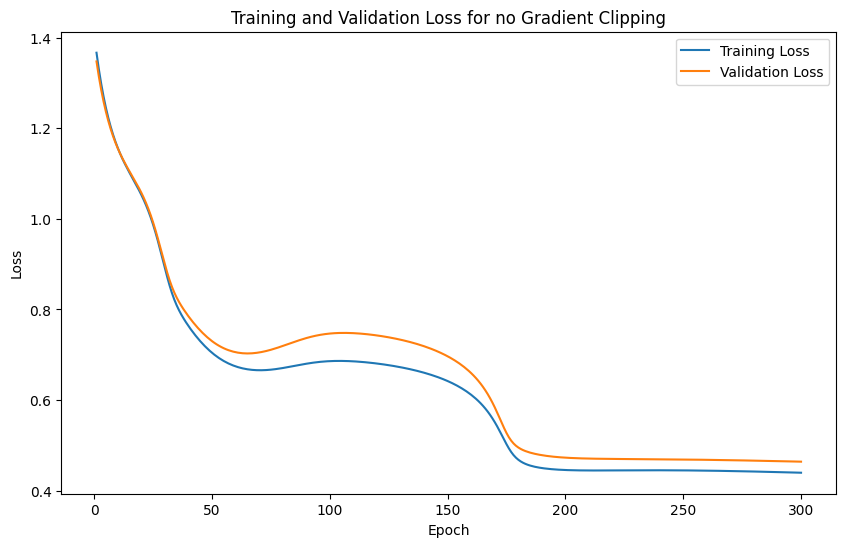

In [12]:
epochs = 300
train_losses_no_clip, val_losses_no_clip, params = train_model(training_set, validation_set, epochs, clip_gradients=False)

print(len(train_losses_no_clip))

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses_no_clip, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_no_clip, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for no Gradient Clipping')
plt.legend()
plt.show()

(64, 4) (64, 64) (4, 64)
Epoch [100/300], Train Loss: 1.2106, Val Loss: 1.2129
Epoch [200/300], Train Loss: 1.0993, Val Loss: 1.1050
Epoch [300/300], Train Loss: 1.0021, Val Loss: 1.0114


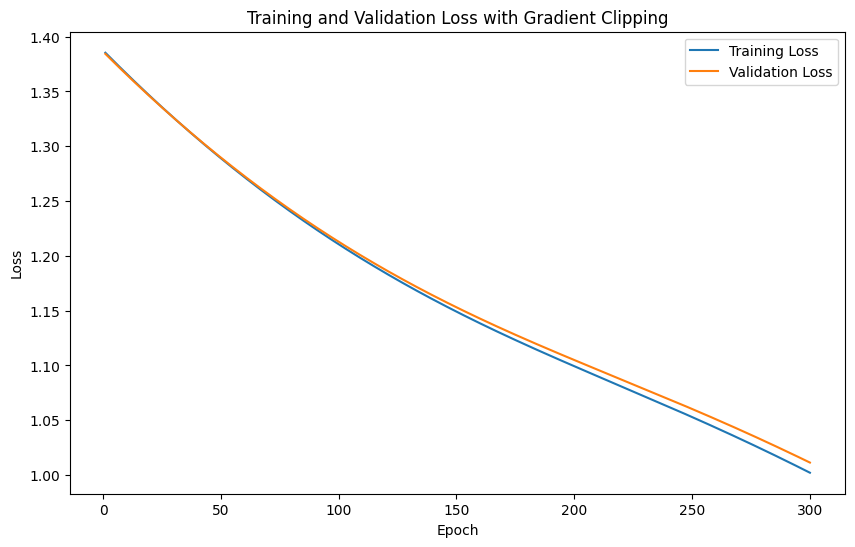

In [13]:
epochs = 300
train_losses_clip, val_losses_clip, params_clip = train_model(training_set, validation_set, epochs, clip_gradients= True)


plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses_clip, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_clip, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss with Gradient Clipping')
plt.legend()
plt.show()

# Test Set
Checking the data in Test data using the params trained during the training set

In [14]:
len(test_set)

10

In [15]:
vocab_size = 4
hidden_units = 64  # Ensure this matches your model's hidden layer size

for sample in test_set:
    inputs, targets = sample
    hidden_state = np.zeros((hidden_units, 1))  # Ensure this shape matches your hidden layer size
    test_encoded_inputs_seq = one_hot_encode_sequence(inputs, vocab_size).squeeze(-1)
    
    # Ensure the shape of the encoded input is correct
    print(f"Encoded inputs shape: {test_encoded_inputs_seq.shape}") 
    
    outputs, hidden_states = forward_pass(test_encoded_inputs_seq, hidden_state, params_clip)  # Forward pass
    
    output_sentence = [idx_to_word[np.argmax(output)] for output in outputs]
    print("Target:", targets)
    print("Output:", output_sentence)


Encoded inputs shape: (2, 4)
Target: ['b', 'EOS']
Output: ['b', 'b']
Encoded inputs shape: (14, 4)
Target: ['a', 'a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'EOS']
Output: ['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b']
Encoded inputs shape: (14, 4)
Target: ['a', 'a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'EOS']
Output: ['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b']
Encoded inputs shape: (16, 4)
Target: ['a', 'a', 'a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'EOS']
Output: ['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b']
Encoded inputs shape: (10, 4)
Target: ['a', 'a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'EOS']
Output: ['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'b']
Encoded inputs shape: (6, 4)
Target: ['a', 'a', 'b', 'b', 'b', 'EOS']
Output: ['b', 'b', 'b', 'b', 'b', 'b']
Encoded inputs shape: (16, 4)
Target: ['a', 'a', 'a', 'a', 'a', 'a', 'a', 'b', 'b'

## Inferences and Conclusion : State all the key observations and conclusion
- Gradient clipping helps to learn the model quickly and efficiently
- RNN model able to learn properly

#**Problem 2** : Demonstrate the same for a Sine Wave

Objective : Given a sequence of 50 numbers belonging to a sine wave, predict the 51st number in the series.

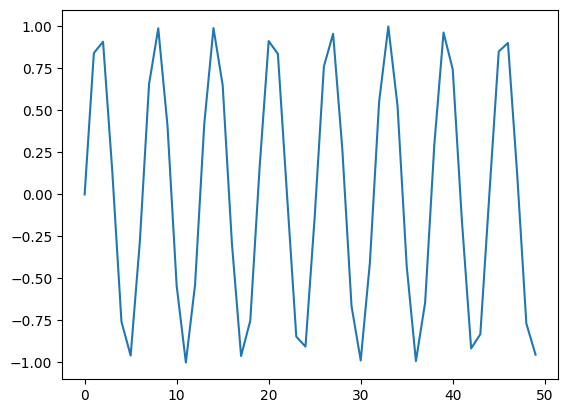

In [16]:
## Write your code here

import math

sin_wave = np.array([math.sin(x) for x in np.arange(200)])

plt.plot(sin_wave[:50])

In [22]:
# Prepare Data for RNN
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):

        x = data[i:i + seq_length]
        #print(x)
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
        #print("i = ", i, " y = ", y)
    return np.array(xs), np.array(ys)

# Create sequences
sequence_length = 50  # Length of input sequences
X, y = create_sequences(sin_wave, sequence_length)

# Convert to PyTorch tensors and reshape
X = torch.FloatTensor(X).unsqueeze(-1)  # Shape: (num_samples, seq_length, 1)
y = torch.FloatTensor(y).unsqueeze(-1)   # Shape: (num_samples, 1)

# Print shapes
print(f'Input shape: {X.shape}, Target shape: {y.shape}')

Input shape: torch.Size([150, 50, 1]), Target shape: torch.Size([150, 1])


Epoch [50/100], Loss: 0.0079
Epoch [100/100], Loss: 0.0001
50
last sequwnce shape (1, 50, 1)
Predicted value: -0.8753


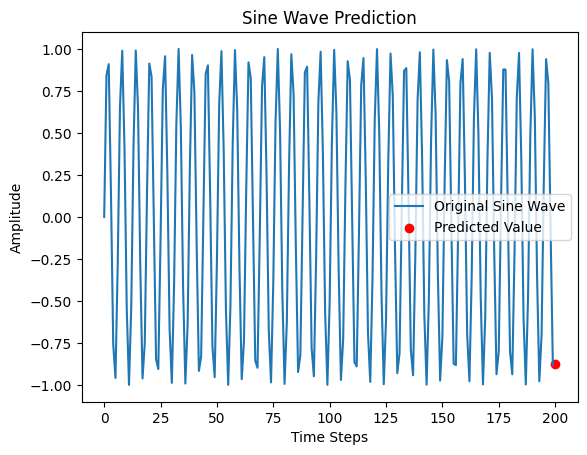

In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.rnn as rnn_utils
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import matplotlib.pyplot as plt
# Define the RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_dim):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)  # Output 1 value

    def forward(self, x):
        #print("length of x", x.shape)
        out, _ = self.rnn(x) # x has shape (batch_size, seq_length, hidden_dim)
        #print(out)
        out = self.fc(out[:, -1, :])  # Use the last time step output, out is .... All batch_size, last time step, all features
        return out

# Model parameters
input_size = 1
hidden_dim = 50
model = RNNModel(input_size, hidden_dim)
print ("==============")

# Step 4: Compile and Train the Model
criterion = nn.MSELoss() # Regression Problem
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)  # Loss calculation should work now
    
    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Make Predictions
# Predict the next value after the last sequence
print(sequence_length)

last_sequence = sin_wave[-sequence_length:].reshape((1, sequence_length, 1))


print("last sequwnce shape", last_sequence.shape)
last_sequence_tensor = torch.FloatTensor(last_sequence)

model.eval()
with torch.no_grad():
    predicted_value = model(last_sequence_tensor)

print(f'Predicted value: {predicted_value.item():.4f}')

# Plot results
plt.plot(sin_wave, label='Original Sine Wave')
plt.scatter(len(sin_wave), predicted_value.item(), color='red', label='Predicted Value')
plt.title('Sine Wave Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

# Inferences

Using Sinewave it was able predict the next sequence correctly